--- Model Evaluation ---
                       precision    recall  f1-score   support

Unlikely to Click (0)       0.95      0.99      0.97       146
  Likely to Click (1)       0.99      0.95      0.97       154

             accuracy                           0.97       300
            macro avg       0.97      0.97      0.97       300
         weighted avg       0.97      0.97      0.97       300



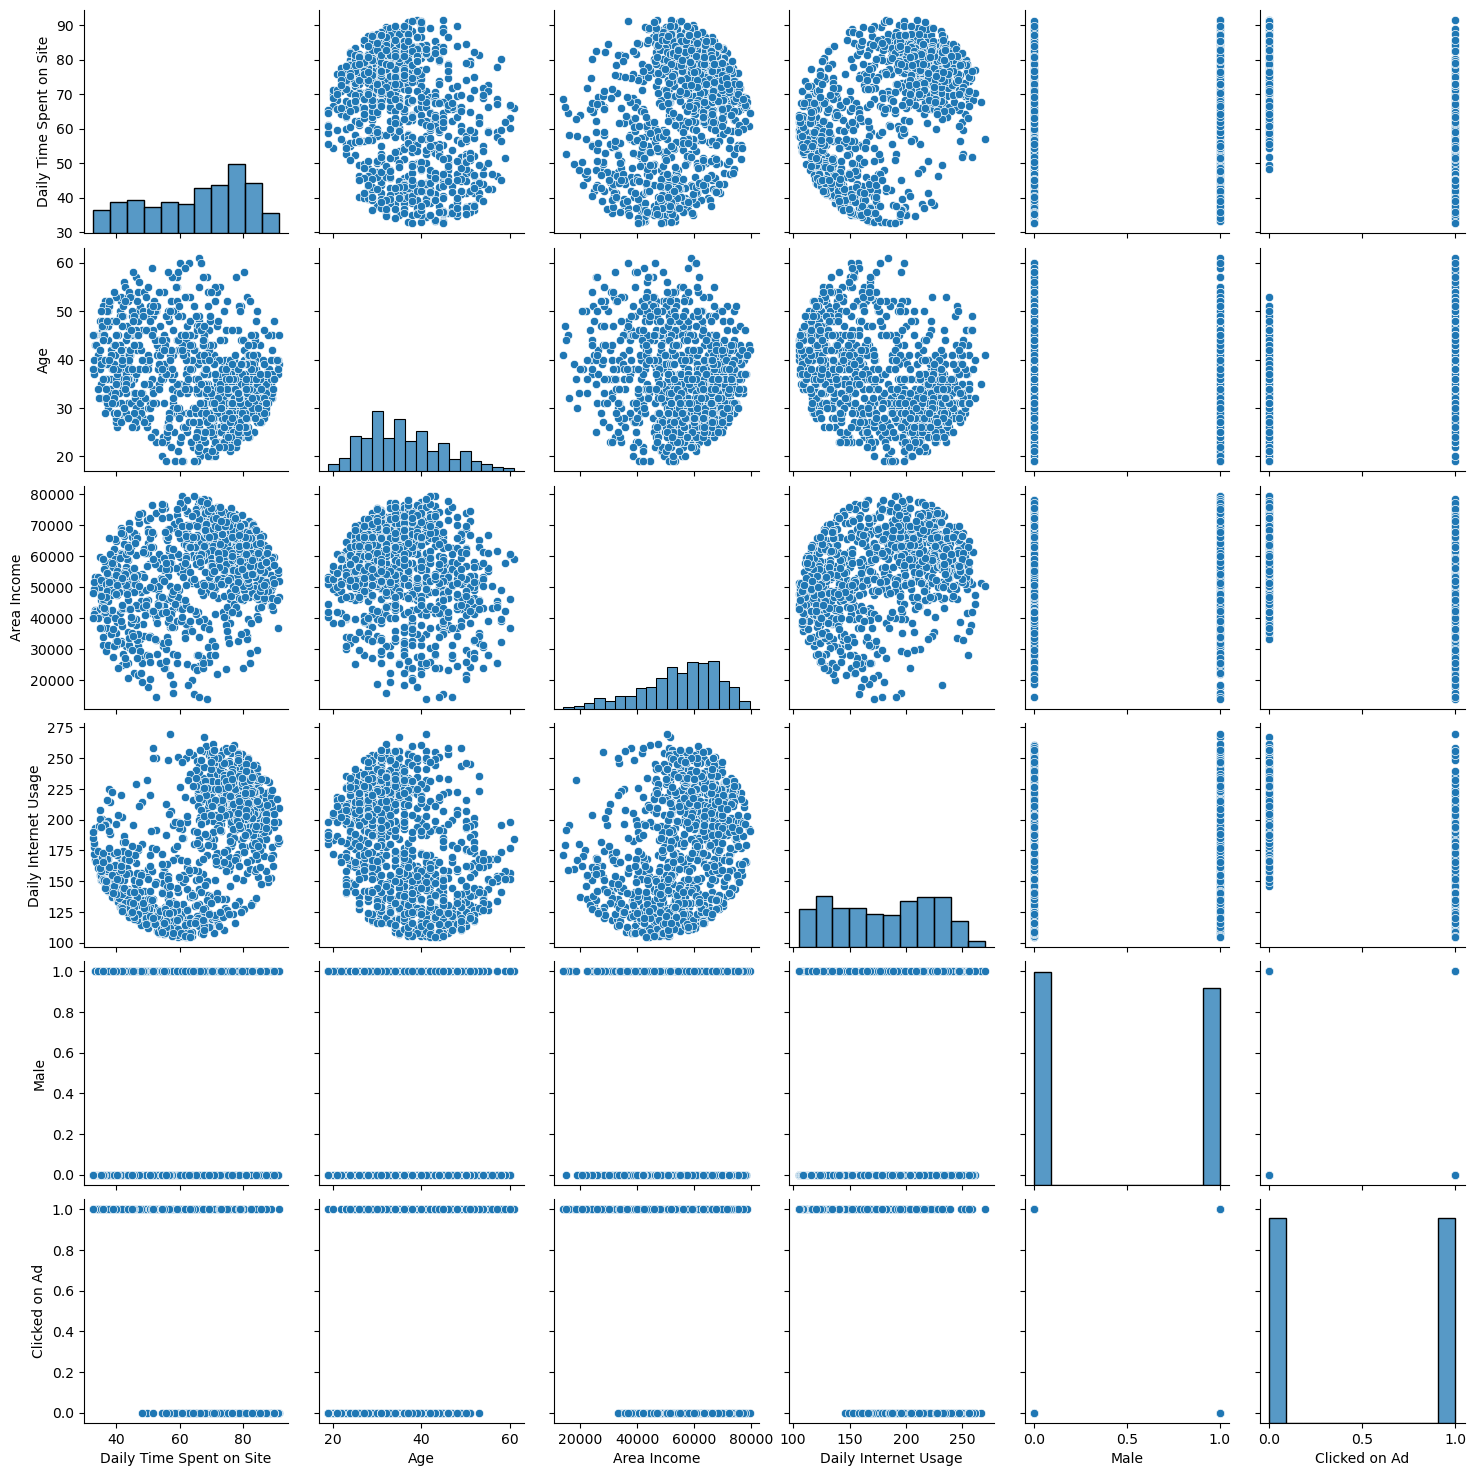

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Load dataset
df = pd.read_csv(r'C:\Users\Soumya_SRB\Desktop\AdClick-Predictor\advertising.csv')

# Separate target and features
X = df.drop(['Clicked on Ad', 'Ad Topic Line', 'City', 'Country', 'Timestamp'], axis=1)
y = df['Clicked on Ad']

# Define feature sets
numerical_features = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']
binary_features = ['Male']

# Set up preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('bin', 'passthrough', binary_features)
    ],
    remainder='drop'
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and train classification pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

model.fit(X_train, y_train)

# Evaluate model
y_pred = model.predict(X_test)

print("--- Model Evaluation ---")
print(classification_report(
    y_test, 
    y_pred, 
    target_names=['Unlikely to Click (0)', 'Likely to Click (1)']
))

# Pairplot visualization
sns.pairplot(df)
plt.show()